<a href="https://colab.research.google.com/github/sanjil18/insurance-prediction-ML-project/blob/main/insurance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load your uploaded file (ensure the filename matches exactly)
df = pd.read_csv('insurance.csv')

# Show the first 5 rows to verify the 7 features
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print(df.isnull().sum())

duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

# Convert categorical text to numbers (One-Hot Encoding)
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separate Features (X) and Target Variable (y)
X = df.drop('charges', axis=1) # All columns except the target
y = df['charges']              # The 'medical insurance cost' target

# Split into Training (80%) and Testing (20%) sets
X_train_1, X_test_1, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_1)
X_test = scaler.transform(X_test_1)

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Number of duplicate rows: 0


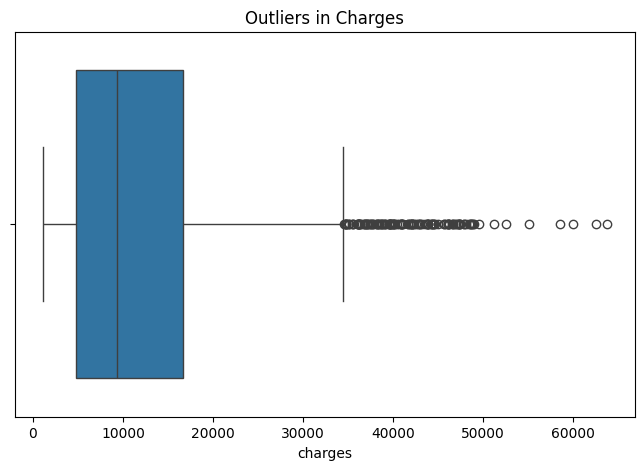

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['charges'])
plt.title('Outliers in Charges')
plt.show()

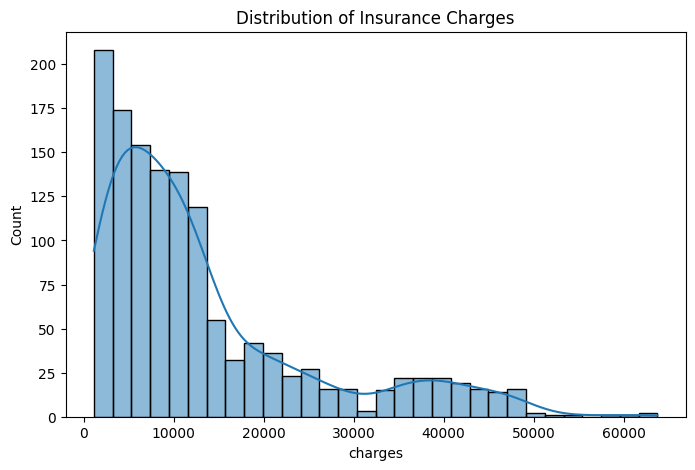

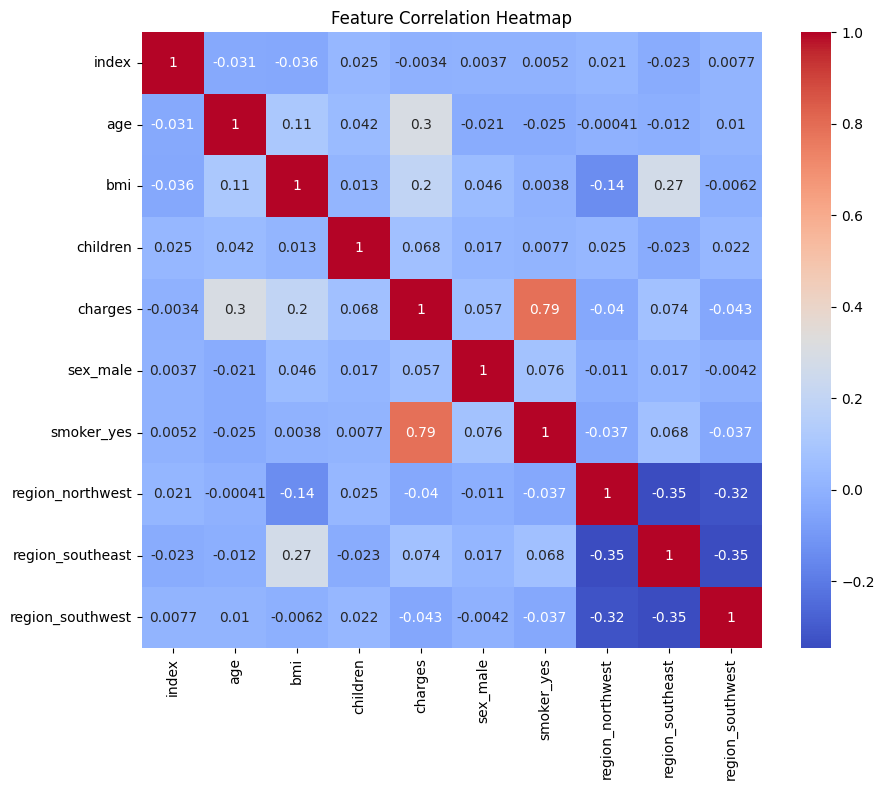

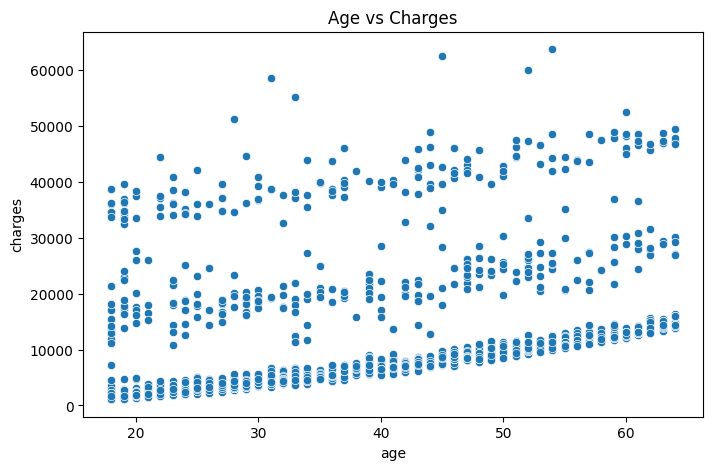

In [4]:
# Distribution of charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Charges vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Charges')
plt.show()

In [7]:
# --- Algorithm 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_train_preds = lr_model.predict(X_train)
lr_test_preds = lr_model.predict(X_test)

# --- Algorithm 2: Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

In [8]:
lr_train_mse=mean_squared_error(y_train,lr_train_preds)
lr_test_mse=mean_squared_error(y_test,lr_test_preds)
lr_train_r2=r2_score(y_train,lr_train_preds)
lr_test_r2=r2_score(y_test,lr_test_preds)
lr_results=pd.DataFrame([["Linear Regression",lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]], columns=['Method','Training MSE','Training R2','Test MSE','Test R2'])

In [9]:
rf_train_mse=mean_squared_error(y_train,rf_train_preds)
rf_test_mse=mean_squared_error(y_test,rf_test_preds)
rf_train_r2=r2_score(y_train,rf_train_preds)
rf_test_r2=r2_score(y_test,rf_test_preds)
rf_results=pd.DataFrame([["Random forest",rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]], columns=['Method','Training MSE','Training R2','Test MSE','Test R2'])

In [15]:
df_model=pd.concat([lr_results,rf_results],axis=0).reset_index()
df_model.drop(columns='index',inplace=True)
df_model



,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,3.723748e+07,0.742004,3.380685e+07,0.782241
1,Random forest,3.420101e+06,0.976304,2.174136e+07,0.859958


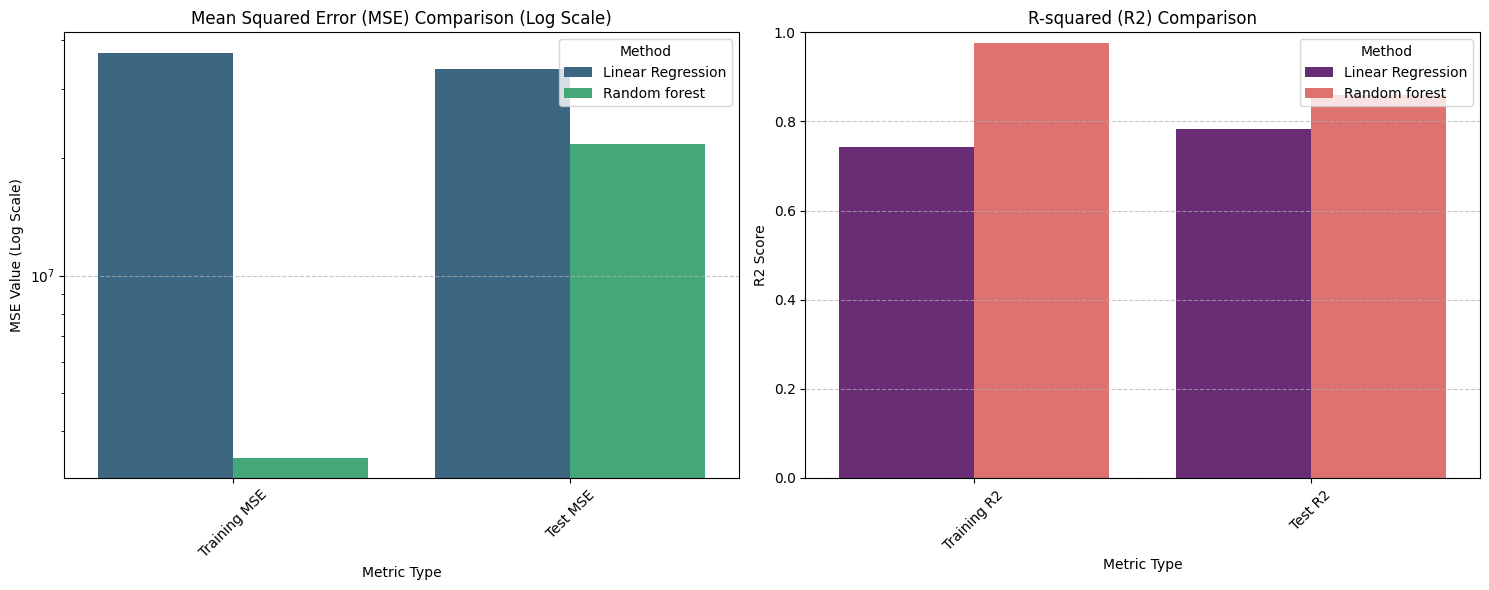

In [16]:
# Reshape the DataFrame for plotting
df_plot = df_model.set_index('Method').stack().reset_index()
df_plot.columns = ['Method', 'Metric', 'Value']

# Separate MSE and R2 metrics
mse_metrics = df_plot[df_plot['Metric'].str.contains('MSE')]
r2_metrics = df_plot[df_plot['Metric'].str.contains('R2')]

plt.figure(figsize=(15, 6))

# Plot MSE with logarithmic scale
plt.subplot(1, 2, 1)
sns.barplot(x='Metric', y='Value', hue='Method', data=mse_metrics, palette='viridis')
plt.title('Mean Squared Error (MSE) Comparison (Log Scale)')
plt.ylabel('MSE Value (Log Scale)')
plt.xlabel('Metric Type')
plt.yscale('log') # Set y-axis to logarithmic scale
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot R2
plt.subplot(1, 2, 2)
sns.barplot(x='Metric', y='Value', hue='Method', data=r2_metrics, palette='magma')
plt.title('R-squared (R2) Comparison')
plt.ylabel('R2 Score')
plt.xlabel('Metric Type')
plt.ylim(0, 1) # R2 scores are typically between 0 and 1
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance (Random Forest)')
plt.show()

In [17]:
import pandas as pd
import numpy as np

def get_user_input():
    """Gets user input for predicting medical insurance costs."""
    print("\nPlease enter the following details to predict medical insurance cost:")
    age = int(input("Age: "))
    sex = input("Sex (male/female): ").lower()
    bmi = float(input("BMI: "))
    children = int(input("Number of children: "))
    smoker = input("Smoker (yes/no): ").lower()
    region = input("Region (northeast/northwest/southeast/southwest): ").lower()

    # Create a dictionary for the input
    user_data = {
        'index': 0, # Add a dummy index to match the training data
        'age': age,
        'bmi': bmi,
        'children': children,
        'sex_male': 1 if sex == 'male' else 0,
        'smoker_yes': 1 if smoker == 'yes' else 0,
        'region_northeast': 1 if region == 'northeast' else 0,
        'region_northwest': 1 if region == 'northwest' else 0,
        'region_southeast': 1 if region == 'southeast' else 0,
        'region_southwest': 1 if region == 'southwest' else 0
    }
    return user_data

# Get user input
user_input_data = get_user_input()

# Convert user input to a DataFrame
# Ensure the columns match X_train_1 exactly, including order and all dummy variables
# X_train_1's columns are: index, age, bmi, children, sex_male, smoker_yes, region_northwest, region_southeast, region_southwest

processed_input = {
    'index': user_input_data['index'],
    'age': user_input_data['age'],
    'bmi': user_input_data['bmi'],
    'children': user_input_data['children'],
    'sex_male': user_input_data['sex_male'],
    'smoker_yes': user_input_data['smoker_yes'],
    'region_northwest': 0, # Default all regions to 0
    'region_southeast': 0,
    'region_southwest': 0
}

# Set the specific region to 1 based on user input, ensuring only one is active
if user_input_data['region_northwest'] == 1:
    processed_input['region_northwest'] = 1
elif user_input_data['region_southeast'] == 1:
    processed_input['region_southeast'] = 1
elif user_input_data['region_southwest'] == 1:
    processed_input['region_southwest'] = 1
# If region was 'northeast', all region_ columns remain 0, which is correct due to drop_first=True

input_df = pd.DataFrame([processed_input])

# The models were trained on scaled data, so the input must also be scaled
# Use the 'scaler' object that was fit on X_train_1
scaled_input = scaler.transform(input_df)

# Make predictions
lr_prediction = lr_model.predict(scaled_input)[0]
rf_prediction = rf_model.predict(scaled_input)[0]

print(f"\n--- Prediction Results for your input ---")
print(f"Linear Regression Prediction: ${lr_prediction:.2f}")
print(f"Random Forest Prediction:   ${rf_prediction:.2f}")


Please enter the following details to predict medical insurance cost:
Age: 32
Sex (male/female): male
BMI: 25
Number of children: 2
Smoker (yes/no): yes
Region (northeast/northwest/southeast/southwest): northeast

--- Prediction Results for your input ---
Linear Regression Prediction: $28834.97
Random Forest Prediction:   $18888.10
